In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)


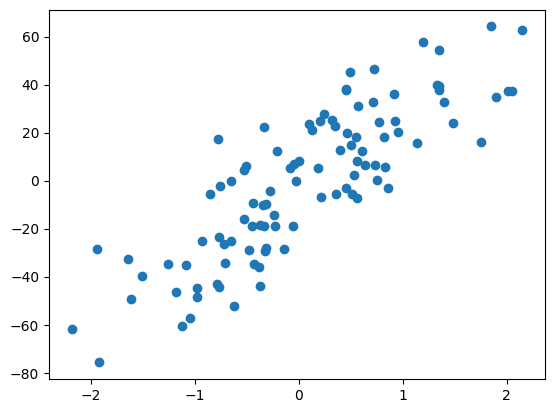

In [3]:
plt.scatter(X,y)

In [4]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)


[27.82809103]
-2.29474455867698


In [5]:
from sklearn.linear_model import Ridge

In [6]:
r=Ridge(alpha=10)
r.fit(X,y)
print(r.coef_)
print(r.intercept_)

[24.9546267]
-2.1269130035235735


In [7]:
r=Ridge(alpha=100)
r.fit(X,y)
print(r.intercept_)
print(r.coef_)

-1.4248441496033308
[12.93442104]


In [8]:
class scratchRidge:

  def __init__(self,alpha=0.1):
    self.alpha=alpha
    self.m=None
    self.b=None

  def fit(self,X,y):
    num=0
    den=0

    for i in range(X.shape[0]):
      num= num + (y - y.mean()) * (X - X.mean())
      den= den + (X - X.mean())*(X - X.mean())

      self.m=num/(den + self.alpha)
      self.b = y.mean() - (self.m*X.mean())
      print(self.m, self.b)


In [9]:
reg=scratchRidge(alpha=100)
#reg.fit(X,y)

In [10]:
from sklearn.datasets import load_diabetes

In [11]:
X,y = load_diabetes(return_X_y=True)


In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=37,test_size=0.2)

In [13]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [14]:
predict=lr.predict(X_test)
predict

array([148.36764655, 193.19168129, 244.02727137, 178.04982261,
        52.73851506,  73.91428096, 193.30754755, 212.06038714,
       182.525738  , 221.78915742, 259.29480149, 251.87324061,
       186.54030845, 116.4136452 , 160.4256357 ,  65.34828734,
       139.11747442,  72.75748182,  92.04790912, 184.80629145,
        69.40276047, 144.45551891, 161.54526891,  67.631094  ,
       173.08385643, 136.66565376, 223.95714507, 219.05254142,
       109.9430828 , 125.16976682, 158.81998947, 157.39035087,
        86.23829575, 148.60325374,  46.54089891, 246.81473725,
       214.27745558, 179.95809483, 114.37343497, 207.94749045,
        33.534301  , 128.22489598, 108.31354201, 158.3425487 ,
       208.10189465, 102.60675523, 230.04655094, 104.0183191 ,
       164.5356643 ,  74.33342029,  59.90438621, 198.20024158,
       153.96283149, 164.944234  ,  77.91551504, 236.61275071,
       181.38005289, 126.29846498, 134.54650552, 113.3192365 ,
       101.67869004, 247.67209636, 139.00582171, 207.89

In [15]:
from sklearn.metrics import r2_score
r2_score(predict,y_test)

0.027769852214783564

In [16]:
lr.coef_

array([ -27.75402306, -273.9551867 ,  495.16993009,  373.52712697,
       -798.60305586,  534.1789761 ,   52.05703259,  148.64249047,
        720.9447616 ,   55.65240207])

# With regularization

In [17]:
class scratchRegularization:
  def __init__(self,alpha=0.1):
    self.alpha=alpha
    self.coef_=None
    self.intercept_=None

  def fit(self,X_train,y_train):
    X_train = np.insert(X_train,0,1,axis=1)
    I= np.identity(X_train.shape[1])
    I[0][0] = 0 #intercept does not need to be updated
    result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
    self.intercept_=result[0]
    self.coef_=result[1:]

  def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_


In [18]:
reg = scratchRegularization()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

0.5047670194053522
[ -15.72064718 -224.91973668  456.68992417  339.6605366   -71.87707916
  -39.55061572 -214.72135259  108.60324539  402.12874482   78.23082037]
152.80391890883425


In [20]:
from sklearn.linear_model import Ridge

In [25]:
#normal regularization
reg1=Ridge(alpha=0.01,solver='sparse_cg',max_iter=500)
reg1.fit(X_train,y_train)
predict=reg1.predict(X_test)
score=r2_score(predict,y_test)
print(reg1.intercept_)
print(reg1.coef_)


152.77054450644818
[ -27.22338699 -265.388242    493.40926139  370.64416439 -358.28090259
  184.46345311 -133.95196469  100.61862198  549.88670563   59.01676126]


In [38]:
#gradient descent l2 regularization
from sklearn.linear_model import SGDRegressor
reg2=SGDRegressor(penalty='l2',max_iter=500,eta0=0.1,alpha=0.001,learning_rate='constant')
reg2.fit(X_train,y_train)
p=reg2.predict(X_test)
r2_score(p,y_test)
print(reg2.intercept_)
print(reg2.coef_)

[127.54850382]
[   6.56897192 -146.89079098  368.09990187  270.20368819  -11.1840587
  -46.63446141 -187.40419133  123.5965198   310.33553589  102.63437646]


In [43]:
#gradient decsent from scratch-

class gdreg:

  def __init__(self,learning_rate,epoch,alpha):
    self.alpha=alpha
    self.learning_rate=learning_rate
    self.epoch=epoch
    self.intercept_=None
    self.coef_=None

  def fit_model(self,X_train,y_train):
    self.coef_ = np.ones(X_train.shape[1])
    self.intercept_ = 0
    thetha = np.insert(self.coef_,0,self.intercept_)

    X_train = np.insert(X_train,0,1,axis=1)
    for i in range(self.epoch):



      theta_der=np.dot(X_train.T,X_train).dot(theta)-np.dot(X_train.T,y_train)+self.alpha*theta
      theta=theta-self.learning_rate*theta_der

    self.coef_=theta[1:]
    self.intercept_=theta[0]
def predict(self,X_test):

        return np.dot(X_test,self.coef_) + self.intercept_

In [44]:
reg3=gdreg(alpha=0.001,epoch=500,learning_rate=0.005)
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.5047670194053522
[ -15.72064718 -224.91973668  456.68992417  339.6605366   -71.87707916
  -39.55061572 -214.72135259  108.60324539  402.12874482   78.23082037]
152.80391890883425
